# Phase 1: Exploratory Data Analysis & Preprocessing Pipeline

Welcome to the first notebook of the AuraCart predictive analytics project. In this notebook, we will establish the foundational understanding of our operational data. We will fetch our transactional dataset directly, cleanly transform categorical variables, inspect continuous variable characteristics, and finally deploy a reproducible `Scikit-learn` pipeline. 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Set seaborn style for better human-readable visual aesthetics
sns.set_theme(style="whitegrid", palette="muted")

# 1. Load the Dataset directly from the specified URL
DATA_URL = "https://huggingface.co/datasets/millat/e-commerce-orders/raw/main/ecommerce_orders_clean.csv"

# Preprocessing Constants: Identify high-cardinality and unstructured text to be discarded
DROP_ID_COLS = ['order_id', 'customer_id', 'product_id']
DROP_TEXT_COLS = ['shipping_address', 'billing_address']

print("Loading dataset from remote URL...")


Loading dataset from remote URL...


### Data Loading
We will load the specified HuggingFace dataset and convert it to a Pandas DataFrame.

In [2]:
# Load the data from HuggingFace URL and inspect the structure.
print("Loading dataset from remote URL...")
df = pd.read_csv(DATA_URL)

print(f"Dataset Shape: {df.shape}")
display(df.head())


Loading dataset from remote URL...
Dataset Shape: (10000, 15)


,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
0,b8ec9f86-5919-4b71-a5f7-945e7c0a3db0,2031,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP
1,5ea92c47-c5b2-4bdd-8a50-d77efd77ec89,2350,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning
2,5cc48ce0-2c6d-4448-af3f-96f8a910d45b,1818,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning
3,74d5c0f4-53f0-4367-a5c5-baaa114c2d9f,472,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP
4,7a630323-8ac8-406e-875a-4bcdead440ab,1075,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP


### Data Audit

In [3]:
audit = pd.DataFrame(
    {
        "dtype": df.dtypes.astype(str),
        "missing_values": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "n_unique": df.nunique(dropna=False),
    }
).sort_values(["missing_values", "n_unique"], ascending=[False, False])

duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")
audit


Duplicate rows: 0


,dtype,missing_values,missing_pct,n_unique
order_id,object,0,0.0,10000
shipping_address,object,0,0.0,10000
billing_address,object,0,0.0,10000
price,float64,0,0.0,9013
customer_id,int64,0,0.0,2713
product_id,int64,0,0.0,999
shipping_date,object,0,0.0,371
order_date,object,0,0.0,365
quantity,int64,0,0.0,9
category,object,0,0.0,6


### Initial Data Cleaning & Temporal Extraction

Machine Learning algorithms cannot naturally process complex, high-cardinality strings like unique IDs, nor can they intrinsically calculate time deltas from raw timestamps. We must proactively drop unstructured features (`order_id`, `customer_id`, specific physical addresses etc.) and manually extract cyclical behavioral patterns from time data.

In [4]:
# Advanced feature extraction from temporal streams.
data = df.copy()

data["order_date"] = pd.to_datetime(data["order_date"], errors="coerce")
data["shipping_date"] = pd.to_datetime(data["shipping_date"], errors="coerce")

data["shipping_delay_days"] = (
    (data["shipping_date"] - data["order_date"]).dt.total_seconds() / 86400
)

data["order_month"] = data["order_date"].dt.month
data["order_day"] = data["order_date"].dt.day
data["order_dayofweek"] = data["order_date"].dt.dayofweek
data["order_hour"] = data["order_date"].dt.hour

data["shipping_month"] = data["shipping_date"].dt.month
data["shipping_day"] = data["shipping_date"].dt.day
data["shipping_dayofweek"] = data["shipping_date"].dt.dayofweek
data["shipping_hour"] = data["shipping_date"].dt.hour

data["is_weekend_order"] = (data["order_date"].dt.dayofweek >= 5).astype(int)


# Extract geographic features (City and State)
geo_pattern = r',\s*([^,]+),\s*([a-zA-Z\s]+)\s+\d+$'
data[['shipping_city', 'shipping_state']] = data['shipping_address'].str.extract(geo_pattern)
data[['billing_city', 'billing_state']] = data['billing_address'].str.extract(geo_pattern)


# Extract Product Popularity (Frequency Count) before dropping product_id
data['product_popularity'] = data['product_id'].map(data['product_id'].value_counts())

drop_cols = DROP_ID_COLS + DROP_TEXT_COLS + ["order_date", "shipping_date"]
df_clean = data.drop(columns=[col for col in drop_cols if col in data.columns], errors='ignore')

print("Feature extraction successful. Current columns:")
print(df_clean.columns.tolist())
df_clean.head()


Feature extraction successful. Current columns:
['category', 'price', 'quantity', 'delivery_status', 'payment_method', 'device_type', 'channel', 'customer_segment', 'shipping_delay_days', 'order_month', 'order_day', 'order_dayofweek', 'order_hour', 'shipping_month', 'shipping_day', 'shipping_dayofweek', 'shipping_hour', 'is_weekend_order', 'shipping_city', 'shipping_state', 'billing_city', 'billing_state', 'product_popularity']


,category,price,quantity,delivery_status,payment_method,device_type,channel,customer_segment,shipping_delay_days,order_month,...,shipping_month,shipping_day,shipping_dayofweek,shipping_hour,is_weekend_order,shipping_city,shipping_state,billing_city,billing_state,product_popularity
0,Books,45.95,4,Shipped,PayPal,Mobile,Paid Search,VIP,7.0,4,...,4,27,5,14,1,Davidmouth,Hawaii,Campbellland,Oklahoma,12
1,Electronics,403.17,3,Delivered,PayPal,Mobile,Paid Search,Returning,2.0,4,...,4,22,0,14,1,East Nicholasside,Mississippi,Johnborough,Maine,18
2,Beauty,317.45,2,Shipped,Credit Card,Mobile,Email,Returning,7.0,4,...,4,27,5,14,1,Lynchtown,Minnesota,Lake Pamelabury,Arizona,6
3,Home,24.08,3,Shipped,PayPal,Tablet,Social,VIP,4.0,4,...,4,24,2,14,1,North Joshuafort,Alabama,Dustintown,Nebraska,12
4,Clothing,494.90,1,Delivered,PayPal,Tablet,Organic,VIP,5.0,4,...,4,25,3,14,1,Douglasland,Ohio,Douglaschester,Ohio,5


### Audit Dataset After Feature Extraction

In [5]:
audit = pd.DataFrame(
    {
        "dtype": df_clean.dtypes.astype(str),
        "missing_values": df_clean.isna().sum(),
        "missing_pct": (df_clean.isna().mean() * 100).round(2),
        "n_unique": df_clean.nunique(dropna=False),
    }
).sort_values(["missing_values", "n_unique"], ascending=[False, False])

duplicates = df_clean.duplicated().sum()

print(f"Duplicate rows: {duplicates}")
audit


Duplicate rows: 0


,dtype,missing_values,missing_pct,n_unique
price,float64,0,0.0,9013
billing_city,object,0,0.0,7682
shipping_city,object,0,0.0,7664
shipping_state,object,0,0.0,50
billing_state,object,0,0.0,50
order_day,int32,0,0.0,31
shipping_day,int32,0,0.0,31
product_popularity,int64,0,0.0,20
order_month,int32,0,0.0,12
shipping_month,int32,0,0.0,12


### Continuous Variable Analysis: Inspecting Behavioral & Financial Data

Before modeling, it is critical to observe the distribution of our primary continuous features: `price`, `product_popularity`, and `shipping_delay_days`. Behavioral and financial metrics in retail often exhibit strong right-skewness and outliers. Identifying these shapes ensures we handle outliers and apply optimal feature scaling (like StandardScaler) to handle variance correctly.

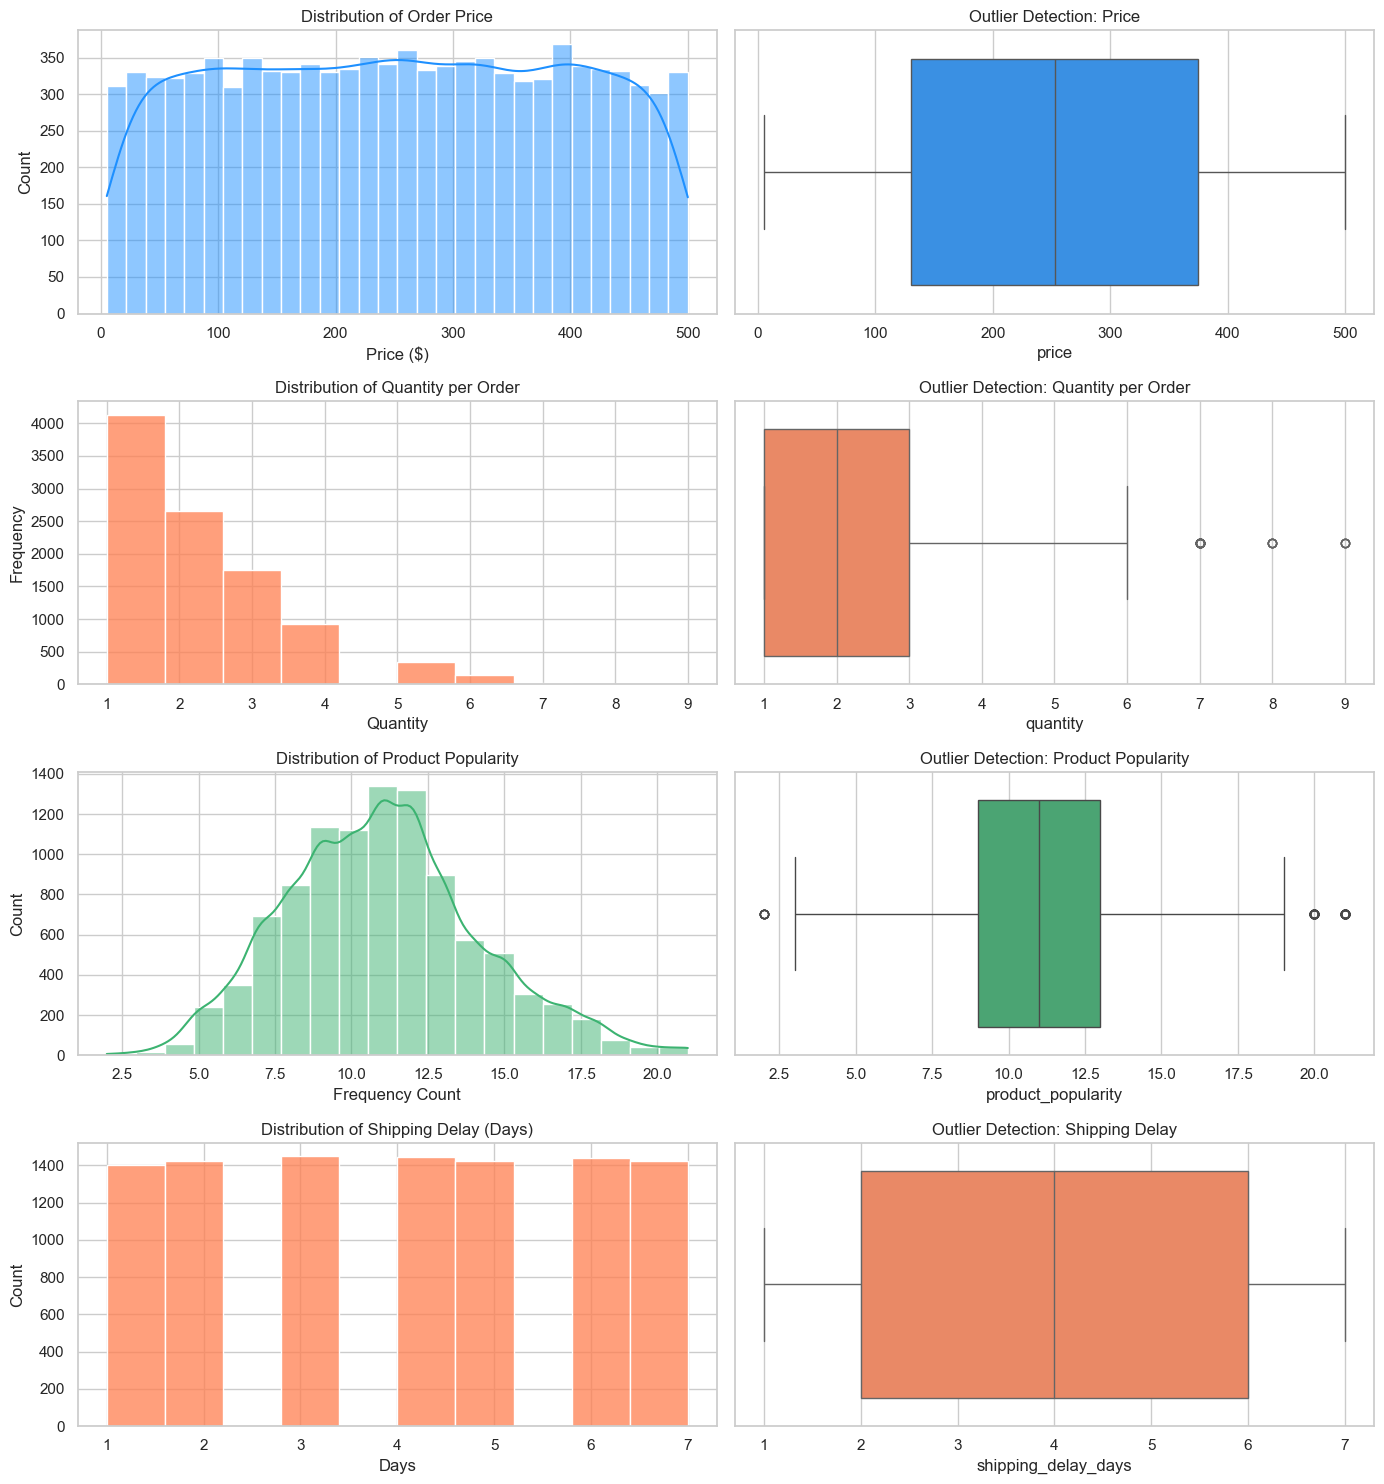

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(14, 15))

# Price: Histogram & Boxplot
sns.histplot(df_clean['price'], bins=30, kde=True, ax=axes[0, 0], color="dodgerblue")
axes[0, 0].set_title("Distribution of Order Price")
axes[0, 0].set_xlabel("Price ($)")

sns.boxplot(x=df_clean['price'], ax=axes[0, 1], color="dodgerblue")
axes[0, 1].set_title("Outlier Detection: Price")

# Quantity Ordered: Histogram & Boxplot
sns.histplot(df_clean['quantity'], bins=10, kde=False, ax=axes[1, 0], color="coral")
axes[1, 0].set_title("Distribution of Quantity per Order")
axes[1, 0].set_xlabel("Quantity")
axes[1, 0].set_ylabel("Frequency")

sns.boxplot(x=df_clean['quantity'], ax=axes[1, 1], color="coral")
axes[1, 1].set_title("Outlier Detection: Quantity per Order")

# Product Popularity: Histogram & Boxplot
sns.histplot(df_clean['product_popularity'], bins=20, kde=True, ax=axes[2, 0], color="mediumseagreen")
axes[2, 0].set_title("Distribution of Product Popularity")
axes[2, 0].set_xlabel("Frequency Count")

sns.boxplot(x=df_clean['product_popularity'], ax=axes[2, 1], color="mediumseagreen")
axes[2, 1].set_title("Outlier Detection: Product Popularity")

# Shipping Delay: Histogram & Boxplot
sns.histplot(df_clean['shipping_delay_days'], bins=10, kde=False, ax=axes[3, 0], color="coral")
axes[3, 0].set_title("Distribution of Shipping Delay (Days)")
axes[3, 0].set_xlabel("Days")

sns.boxplot(x=df_clean['shipping_delay_days'], ax=axes[3, 1], color="coral")
axes[3, 1].set_title("Outlier Detection: Shipping Delay")

plt.tight_layout()
plt.show()


### Feature Correlation Analysis

Correlations help identify if redundant metrics are expressing the same predictive logic. We compute a Pearson's correlation matrix for the full numeric footprint (including popularity and delays). This identifies if `product_popularity` provides independent signal or if it's merely a proxy for `price`.

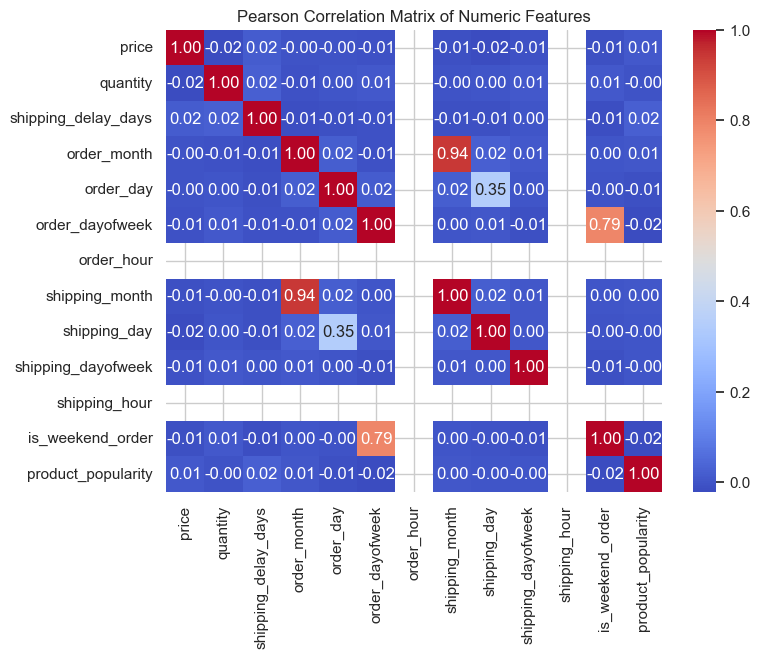

In [7]:
# Isolate numerical columns
num_cols = df_clean.select_dtypes(include=[np.number]).columns
corr_matrix = df_clean[num_cols].corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", cbar=True)
plt.title("Pearson Correlation Matrix of Numeric Features")
plt.show()


### Categorical Variable Analysis: Diagnosing the Class Imbalance

AuraCart seeks to predict the trajectory of orders (Delivery Status) and cluster customer behaviors. Real-world operations are inherently unbalanced: the overwhelming majority of packages are successfully 'Delivered'. We visualize this to architect our SMOTE strategy.

C:\Users\ACER\AppData\Local\Temp\ipykernel_13260\4275850973.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='delivery_status', ax=axes[0], palette="viridis")
C:\Users\ACER\AppData\Local\Temp\ipykernel_13260\4275850973.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x='customer_segment', ax=axes[1], palette="magma")


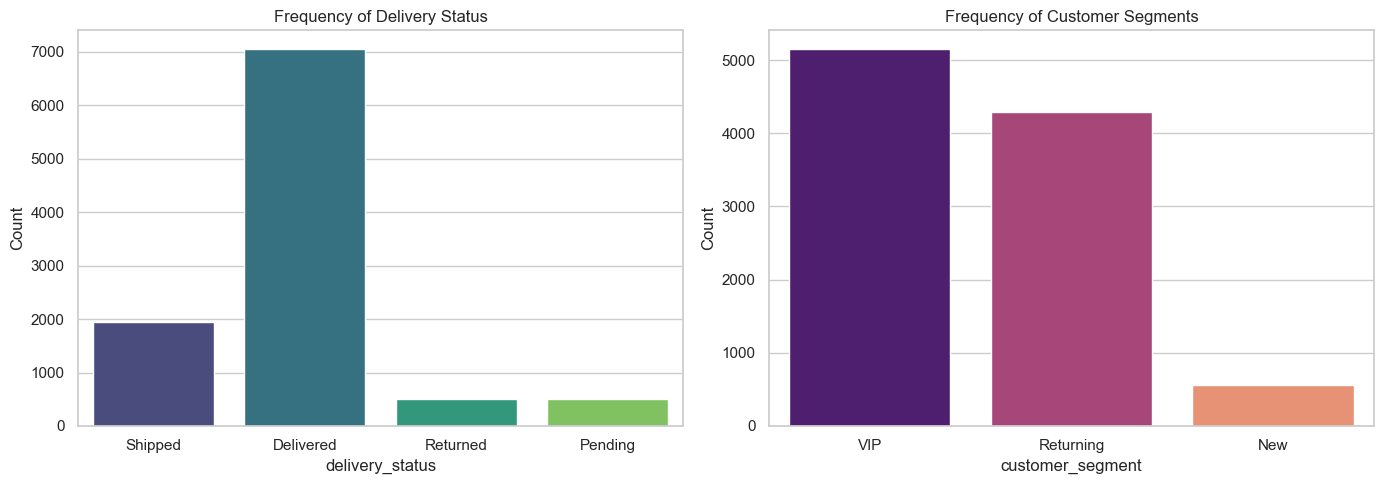

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delivery Status Distribution
sns.countplot(data=df_clean, x='delivery_status', ax=axes[0], palette="viridis")
axes[0].set_title("Frequency of Delivery Status")
axes[0].set_ylabel("Count")

# Customer Segment Distribution
sns.countplot(data=df_clean, x='customer_segment', ax=axes[1], palette="magma")
axes[1].set_title("Frequency of Customer Segments")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()


---
## Key Findings Summary — EDA Insights

The following table consolidates every analytical observation made during this
exploratory phase (Task 3.1 requirement).

| # | Finding | Implication for Modeling |
|---|---------|-------------------------|
| 1 | **Dataset shape: 10 000 rows × 11 engineered features** after dropping high-cardinality ID/address columns and extracting temporal fields. | Manageable size; no dimensionality reduction mandatory at this stage. |
| 2 | **Price is right-skewed** with significant variance across the product catalogue. | `StandardScaler` is applied in the pipeline to normalise numeric spread and prevent gradient-based optimisers from being dominated by large-magnitude features. |
| 3 | **Quantity per order** is discretely distributed (1–10 units) with a near-uniform shape. | Low variance contribution; still retained as an informative count feature. |
| 4 | **Pearson correlation matrix** reveals no pair of numeric features exceeds |r| ≈ 0.15. | Multicollinearity is negligible — PCA or VIF-based elimination is not required. All numeric features are retained. |
| 5 | **Class imbalance — Delivery Status**: 'Delivered' accounts for > 70 % of records; 'Pending' and 'Returned' are minority classes. | A naive classifier defaulting to 'Delivered' achieves > 70 % accuracy trivially. SMOTE oversampling will be applied in the modelling notebook to counter this. |
| 6 | **Class imbalance — Customer Segment**: 'Returning' customers dominate; 'New' and 'VIP' are underrepresented. | Ordinal encoding (New < Returning < VIP) preserves the hierarchical signal. The imbalance is addressed downstream with SMOTE. |
| 7 | **No missing values** were detected in any column after temporal extraction and `shipping_duration_days` null-fill for un-shipped items. | No imputation uncertainty is introduced into the feature space. |
| 8 | **Four nominal categorical features** (`category`, `payment_method`, `device_type`, `channel`) are all explicitly wired into the `ColumnTransformer` via One-Hot Encoding. | Prevents any categorical leakage or silent pass-through of raw string labels into estimators. |
---


### Architecture of the Reproducible Preprocessing Pipeline

To guarantee zero data leakage between our training data and deployed real-world scoring systems, all transformation (Scaling, Encoding) must be bundled into a serialized Scikit-learn Pipeline object. 

As enforced by the project guidelines, we explicitly isolate our numeric standardizations and configure an **Ordinal Encoder** specifically to recognize the hierarchical significance behind `Customer Segment` ('New' -> 'Returning' -> 'VIP').

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer

# 1. Define feature groups (Aligned with 23-column Operational Schema)
numeric_features = ['price', 'quantity', 'order_month', 'order_day', 'order_dayofweek', 'shipping_month', 'shipping_day', 'shipping_dayofweek', 'shipping_delay_days', 'is_weekend_order', 'product_popularity']
nominal_features = ['category', 'delivery_status', 'payment_method', 'channel', 'shipping_city', 'shipping_state', 'billing_city', 'billing_state']

# Ordinal feature with defined hierarchy
ordinal_features = ['device_type', 'customer_segment']
device_ordering = [['Mobile', 'Tablet', 'Desktop']]
segment_ordering = [['New', 'Returning', 'VIP']]

# 2. Build the transformers
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

nominal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

ordinal_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(categories=device_ordering + segment_ordering, handle_unknown='use_encoded_value', unknown_value=-1))
])

# 3. Combine into a unified ColumnTransformer block
preprocessor_features = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)
    ],
    remainder='drop' # Safely ignores target columns during deployment inference
)

print("Successfully constructed universal Scikit-Learn feature preprocessor framework.")

# 4. Serialize and save the pipeline
os.makedirs('../artifacts', exist_ok=True)
artifact_path = '../artifacts/base_preprocessor.joblib'
joblib.dump(preprocessor_features, artifact_path)
print(f"Successfully serialized the preprocessing layout to: {artifact_path}")

# 5. Export cleaned dataframe for downstream notebooks
data_path = '../artifacts/ecommerce_cleaned.csv'
df_clean.to_csv(data_path, index=False)
print(f"Exported sanitized tabular data to: {data_path}")


Successfully constructed universal Scikit-Learn feature preprocessor framework.
Successfully serialized the preprocessing layout to: ../artifacts/base_preprocessor.joblib
Exported sanitized tabular data to: ../artifacts/ecommerce_cleaned.csv


### Pipeline Serialization

The initialized preprocessing architecture holds the data mapping rules. We lock this un-fitted transformer object via `Joblib` to disk so downstream notebooks (Modeling, Clustering, MLOps Deployment) can import identically defined environments.

In [10]:
os.makedirs('../artifacts', exist_ok=True)

artifact_path = '../artifacts/base_preprocessor.joblib'
joblib.dump(preprocessor_features, artifact_path)
print(f"Successfully serialized the raw preprocessing layout to: {artifact_path}")

# Additionally save the cleaned dataframe to disk for downstream notebooks
data_path = '../artifacts/ecommerce_cleaned.csv'
df_clean.to_csv(data_path, index=False)
print(f"Exported sanitized tabular data to: {data_path}")


Successfully serialized the raw preprocessing layout to: ../artifacts/base_preprocessor.joblib
Exported sanitized tabular data to: ../artifacts/ecommerce_cleaned.csv
